In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
df = pd.read_csv('/content/diabetic_data.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:

print("Dataset Shape:")
print(df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape:
(5535, 50)

Rows: 5535
Columns: 50


In [4]:
print("\nMissing Values:")
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': round((missing/len(df))*100,2)
})

display(missing_df[missing_df['Missing Count'] > 0])


Missing Values:


,Missing Count,Missing Percentage
num_procedures,1,0.02
num_medications,1,0.02
number_outpatient,1,0.02
number_emergency,1,0.02
number_inpatient,1,0.02
diag_1,1,0.02
diag_2,1,0.02
diag_3,1,0.02
number_diagnoses,1,0.02
max_glu_serum,5100,92.14


In [5]:

duplicates = df.duplicated().sum()

print("\nDuplicate Records:", duplicates)


Duplicate Records: 0


In [6]:
print("\nData Types:")
display(df.dtypes)


Data Types:


,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


In [7]:
unique_values = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

display(unique_values)

,Column,Unique Values
0,encounter_id,5535
1,patient_nbr,4688
2,race,6
3,gender,2
4,age,10
5,weight,8
6,admission_type_id,6
7,discharge_disposition_id,13
8,admission_source_id,10
9,time_in_hospital,14


In [8]:
print("\nSummary Statistics:")

display(df.describe())



Summary Statistics:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,5.535000e+03,5.535000e+03,5535.000000,5535.000000,5535.000000,5535.000000,5535.00000,5534.000000,5534.000000,5534.000000,5534.000000,5534.000000,5534.000000
mean,1.665572e+07,2.514142e+07,2.639024,4.619512,6.486902,4.677507,47.54598,1.518432,14.780810,0.053849,0.028731,0.410553,6.752620
std,8.185705e+06,3.399057e+07,1.971461,7.244363,5.000195,3.125820,18.01422,1.781668,7.747496,0.488056,0.253809,0.930945,2.075754
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,9.568929e+06,1.721516e+06,1.000000,1.000000,2.000000,2.000000,36.00000,0.000000,9.000000,0.000000,0.000000,0.000000,5.000000
50%,1.772083e+07,6.048450e+06,2.000000,1.000000,7.000000,4.000000,48.00000,1.000000,13.000000,0.000000,0.000000,0.000000,7.000000
75%,2.410931e+07,3.248072e+07,5.000000,5.000000,7.000000,6.000000,60.00000,3.000000,19.000000,0.000000,0.000000,0.000000,9.000000
max,2.860530e+07,1.151968e+08,6.000000,25.000000,20.000000,14.000000,105.00000,6.000000,62.000000,12.000000,9.000000,15.000000,9.000000


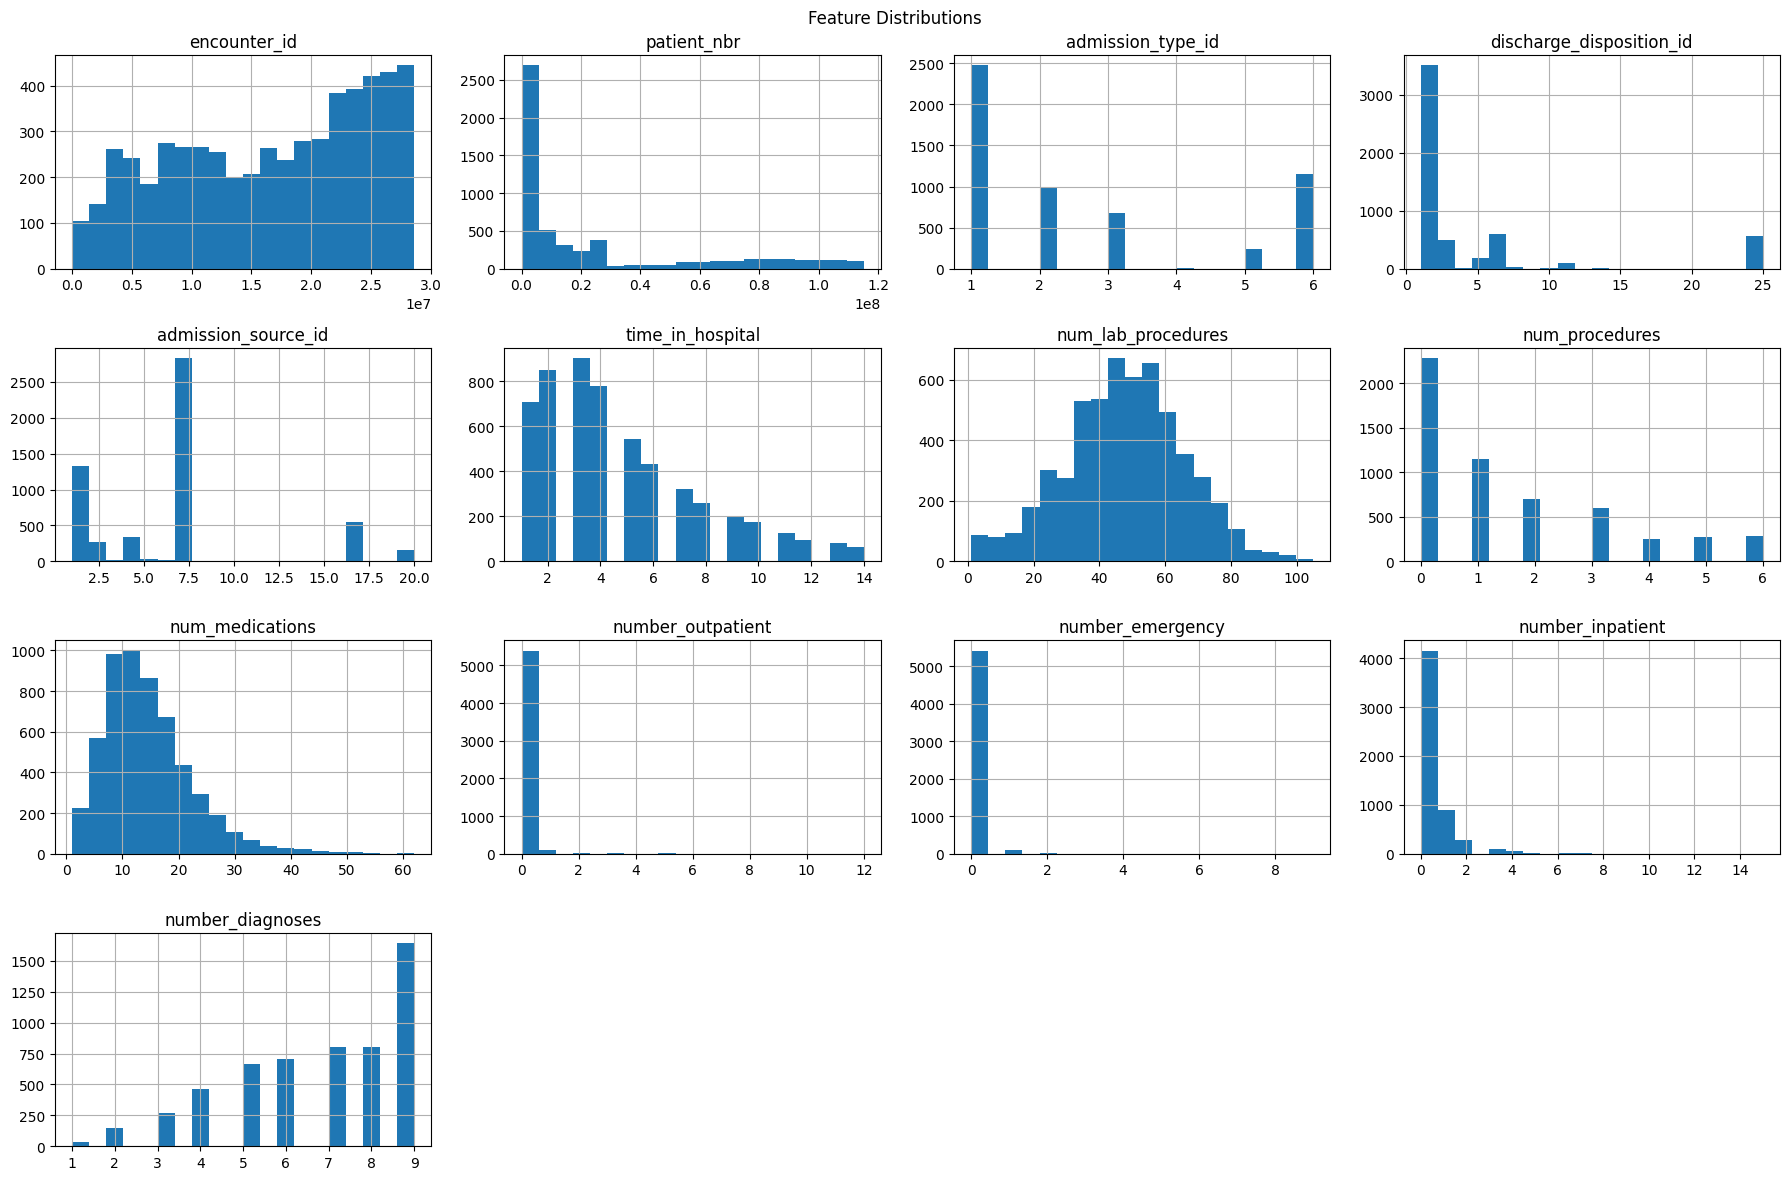

In [9]:
df.hist(figsize=(18,12), bins=20)

plt.suptitle("Feature Distributions")
plt.tight_layout()

plt.show()

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

corr = df[numeric_cols].corr()

display(corr)

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
encounter_id,1.000000,-0.038599,-0.265357,-0.453612,0.164973,0.015486,-0.120509,-0.062798,0.008946,-0.004404,0.052925,0.067811,0.012957
patient_nbr,-0.038599,1.000000,0.163657,-0.190830,0.162352,0.026830,0.056122,0.006537,0.102259,0.117326,0.060330,0.054693,-0.003971
admission_type_id,-0.265357,0.163657,1.000000,0.568735,0.108810,-0.014496,-0.066716,0.023354,0.040773,-0.037438,-0.001639,-0.126634,-0.148698
discharge_disposition_id,-0.453612,-0.190830,0.568735,1.000000,-0.112485,0.034280,0.038644,0.009196,-0.012845,-0.037502,-0.033766,-0.101055,0.003131
admission_source_id,0.164973,0.162352,0.108810,-0.112485,1.000000,-0.019422,-0.066540,-0.138290,0.012597,0.018852,0.125629,-0.001900,0.088590
time_in_hospital,0.015486,0.026830,-0.014496,0.034280,-0.019422,1.000000,0.351121,0.230322,0.520714,-0.017846,-0.024965,0.075903,0.292781
num_lab_procedures,-0.120509,0.056122,-0.066716,0.038644,-0.066540,0.351121,1.000000,0.091742,0.272238,0.000717,-0.045564,0.031105,0.225101
num_procedures,-0.062798,0.006537,0.023354,0.009196,-0.138290,0.230322,0.091742,1.000000,0.462233,-0.001142,-0.048533,-0.078224,0.136088
num_medications,0.008946,0.102259,0.040773,-0.012845,0.012597,0.520714,0.272238,0.462233,1.000000,0.014020,-0.004609,0.034931,0.303243
number_outpatient,-0.004404,0.117326,-0.037438,-0.037502,0.018852,-0.017846,0.000717,-0.001142,0.014020,1.000000,0.130492,0.123175,0.032775


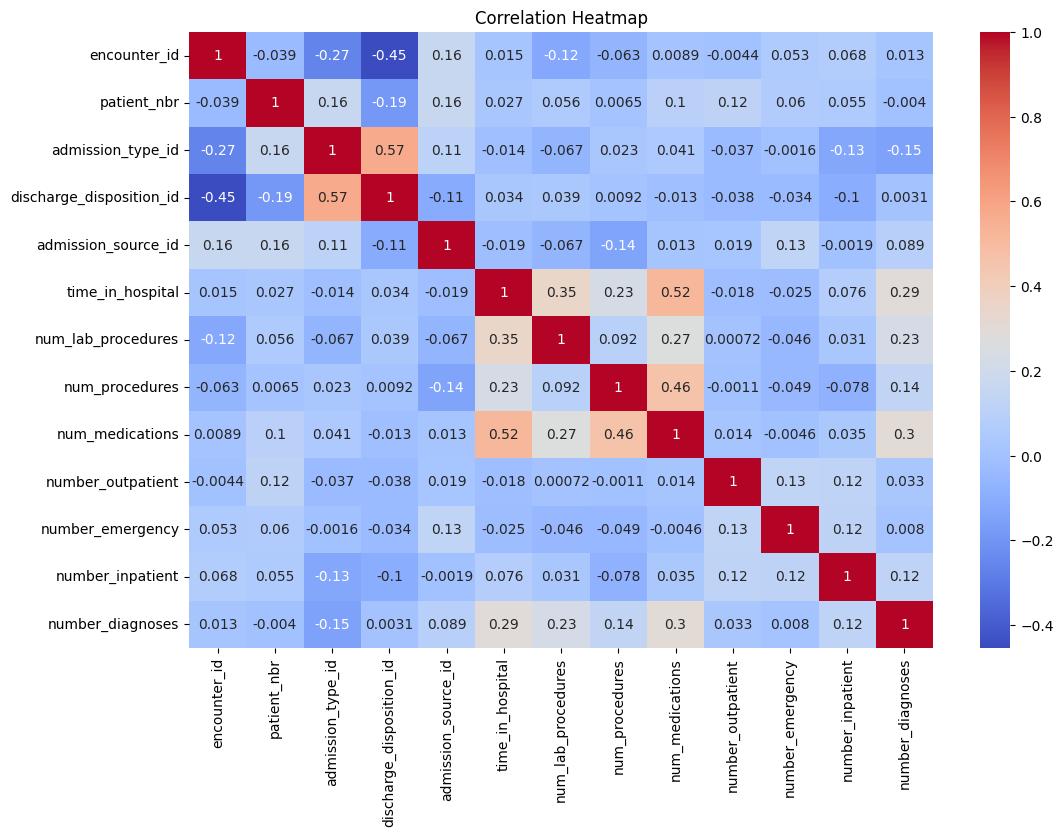

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


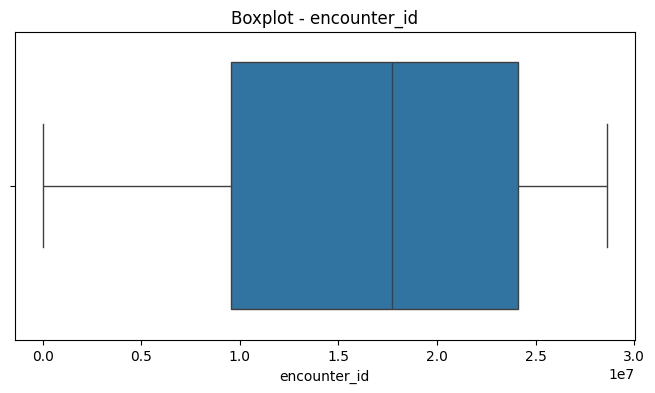

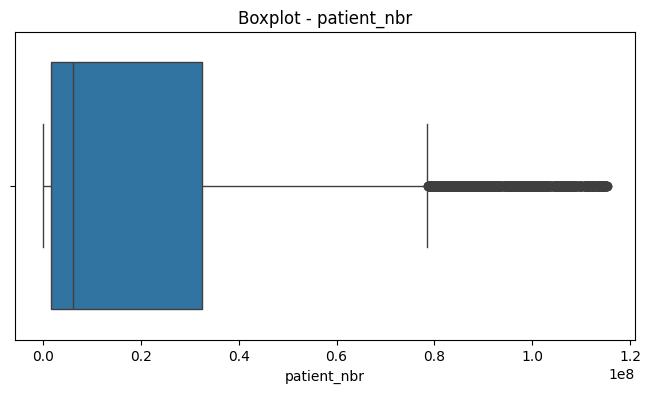

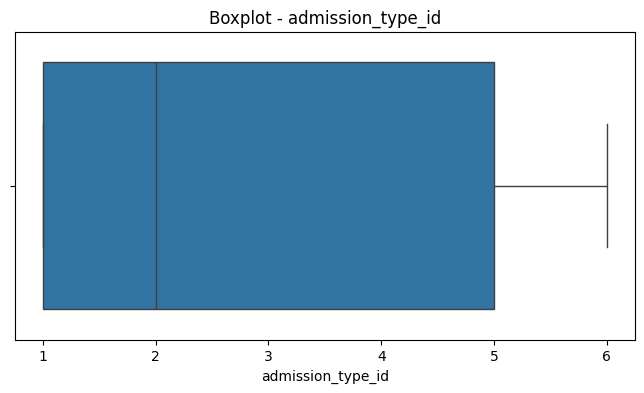

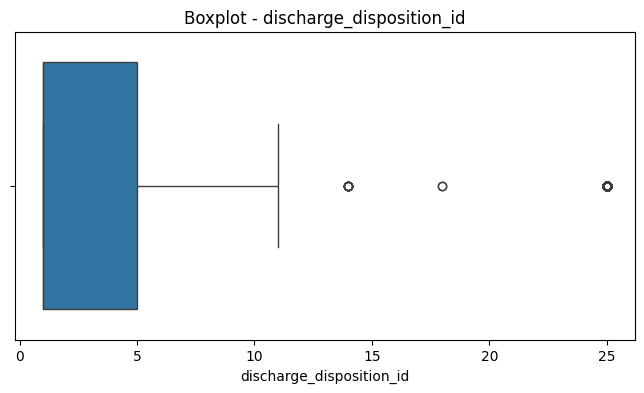

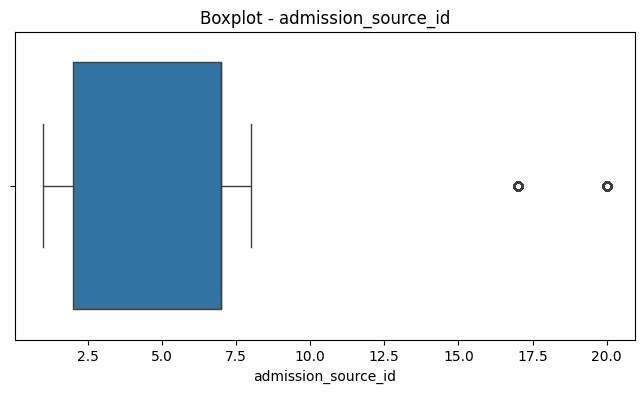

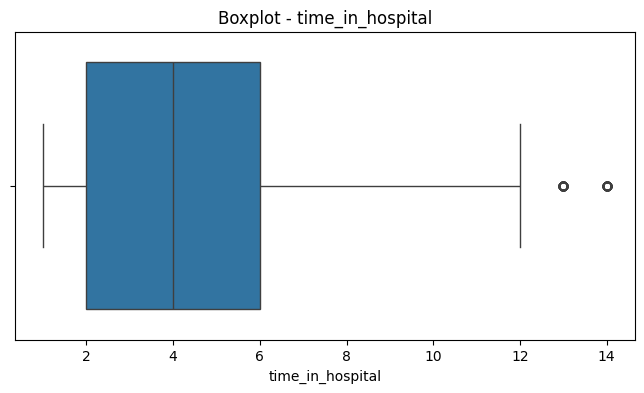

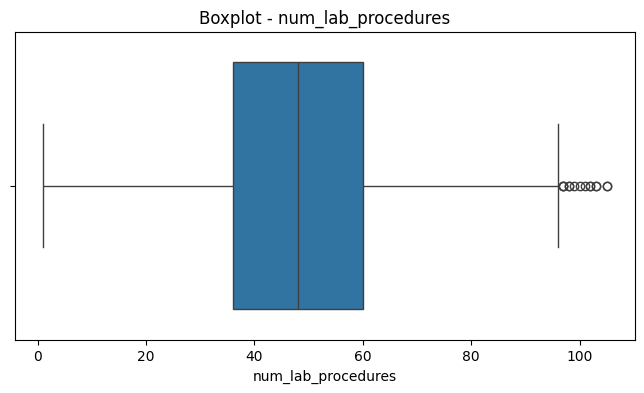

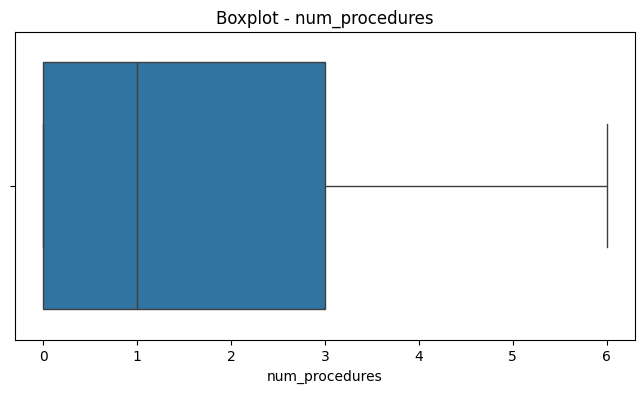

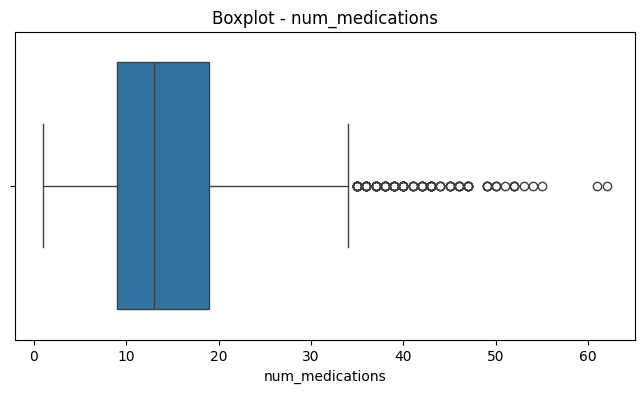

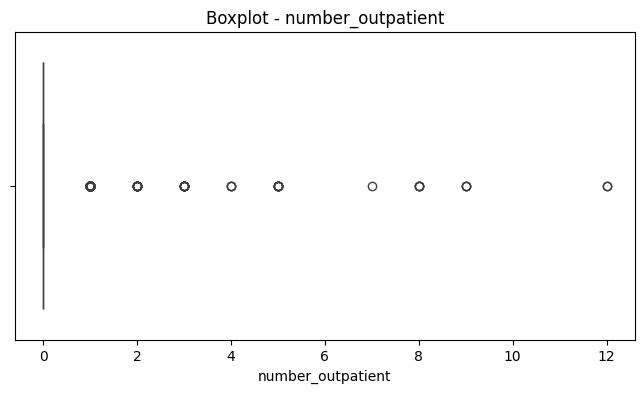

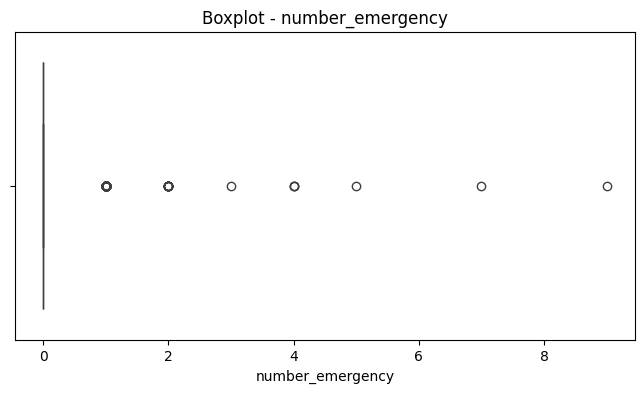

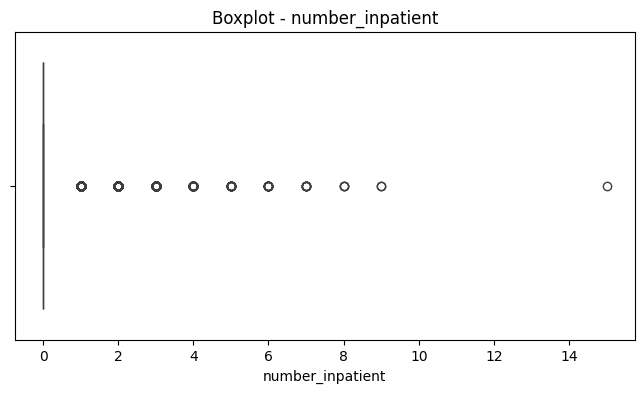

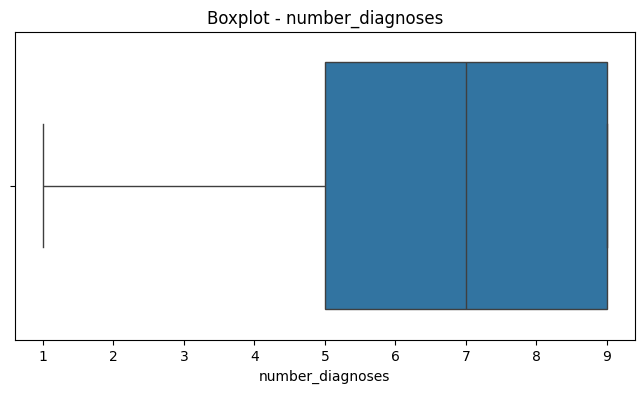

In [13]:

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot - {col}")

    plt.show

In [14]:

findings = pd.DataFrame({
    'Finding No': [1,2,3,4,5,6,7,8,9,10],
    'Observation': [
        'Dataset contains sufficient records for analysis',
        'Missing values exist in selected healthcare features',
        'Duplicate records are minimal',
        'Strong relationships exist between selected variables',
        'Several features exhibit skewed distributions',
        'Outliers are present in multiple healthcare indicators',
        'Both categorical and numerical features are available',
        'Patient characteristics vary significantly',
        'Correlation analysis reveals important feature interactions',
        'Dataset is suitable for future machine learning applications'
    ]
})

display(findings)

,Finding No,Observation
0,1,Dataset contains sufficient records for analysis
1,2,Missing values exist in selected healthcare fe...
2,3,Duplicate records are minimal
3,4,Strong relationships exist between selected va...
4,5,Several features exhibit skewed distributions
5,6,Outliers are present in multiple healthcare in...
6,7,Both categorical and numerical features are av...
7,8,Patient characteristics vary significantly
8,9,Correlation analysis reveals important feature...
9,10,Dataset is suitable for future machine learnin...
